In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")

In [26]:
df = pd.read_csv("adult.csv")
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48842 non-null  int64
 1   workclass        48842 non-null  str  
 2   fnlwgt           48842 non-null  int64
 3   education        48842 non-null  str  
 4   educational-num  48842 non-null  int64
 5   marital-status   48842 non-null  str  
 6   occupation       48842 non-null  str  
 7   relationship     48842 non-null  str  
 8   race             48842 non-null  str  
 9   gender           48842 non-null  str  
 10  capital-gain     48842 non-null  int64
 11  capital-loss     48842 non-null  int64
 12  hours-per-week   48842 non-null  int64
 13  native-country   48842 non-null  str  
 14  income           48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


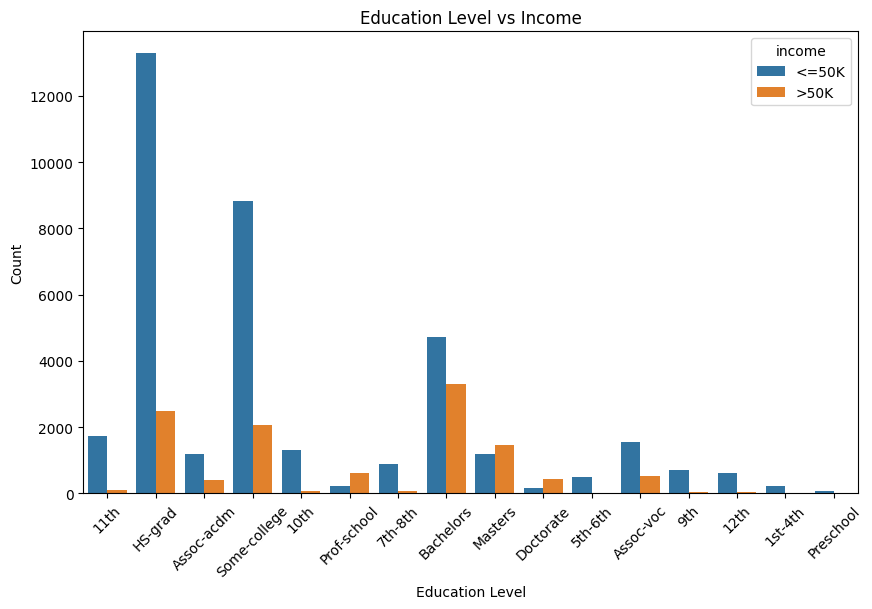

In [35]:
plt.figure(figsize=(10, 6))
sns.countplot(x="education", hue="income", data=df)
plt.xticks(rotation=45)
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.title("Education Level vs Income")
plt.show()

In [29]:
data = df[['age', 'education', 'income','hours-per-week', 'gender']]
encoder = LabelEncoder()
data['income'] = encoder.fit_transform(data['income'])
data['gender'] = encoder.fit_transform(data['gender'])
X = pd.get_dummies(data, columns=['education'])
X


,age,income,hours-per-week,gender,education_10th,education_11th,education_12th,education_1st-4th,education_5th-6th,education_7th-8th,education_9th,education_Assoc-acdm,education_Assoc-voc,education_Bachelors,education_Doctorate,education_HS-grad,education_Masters,education_Preschool,education_Prof-school,education_Some-college
0,25,0,40,1,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,38,0,50,1,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
2,28,1,40,1,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
3,44,1,40,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
4,18,0,30,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,0,38,0,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
48838,40,1,40,1,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
48839,58,0,40,0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
48840,22,0,20,1,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False


In [30]:
X_train, X_test, y_train, y_test = train_test_split(X.drop('income', axis=1), X['income'], test_size=0.2, random_state=42)

In [31]:
model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)
accuracy_lr = model_lr.score(X_test, y_test)
print(f"Logistic Regression Accuracy: {accuracy_lr:.2f}")

Logistic Regression Accuracy: 0.80


In [32]:
model_svc = SVC()
model_svc.fit(X_train, y_train)
accuracy_svc = model_svc.score(X_test, y_test)
print(f"SVM Accuracy: {accuracy_svc:.2f}")

SVM Accuracy: 0.77


## Выводы по проделанной работе

### a) Преобразования данных
- Из исходного набора оставлены признаки `age`, `education`, `hours-per-week`, `gender`, `income`.
- `income` и `gender` закодированы через `LabelEncoder` (0/1).
- `education` преобразован в фиктивные переменные (one‑hot encoding).
- Выполнено разбиение на обучающую (80%) и тестовую (20%) выборки.

### b) Сравнение точности моделей
- Логистическая регрессия: **0.80** (80%)
- SVM (с параметрами по умолчанию): **0.77** (77%)
- Логистическая регрессия оказалась на 3% точнее SVM при использовании выбранных признаков.

### c) Мнение о полноте решения и пути улучшения
Модели **не справились в полной мере**. Достигнутая точность (~80%) — лишь базовый уровень, уступающий лучшим результатам (85–87%) на этом датасете, найденным в интернете.

**Что нужно улучшить:**
- Добавить больше признаков.
- Попробовать балансировку классов (класс `>50K` в меньшинстве).
- Рассмотреть более мощные модели.